# Topic Analysis: Grouping Fake News Articles

This notebook performs topic modeling on the preprocessed fake news dataset to:
- Discover latent topics in the articles
- Group articles by topic
- Analyze differences between fake and real news topics
- Visualize topic distributions
- Compare different topic modeling approaches

**Methods Used:**
- Latent Dirichlet Allocation (LDA)
- Non-negative Matrix Factorization (NMF)
- TF-IDF Vectorization
- Topic Coherence Analysis
- Word Cloud Visualization


## 1. Setup and Imports


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Topic modeling
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.metrics.pairwise import cosine_similarity

# Visualization
from wordcloud import WordCloud

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("✓ All packages imported successfully")


✓ All packages imported successfully


In [2]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")


Project root: /Users/alanye/Fake-News-Group-3


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Topic modeling
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics.pairwise import cosine_similarity

# Visualization
from wordcloud import WordCloud

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("✓ All packages imported successfully")


✓ All packages imported successfully


## 2. Load Preprocessed Data


In [4]:
# Load preprocessed dataset
data_path = project_root / "data" / "processed" / "preprocessed_dataset.csv"

print(f"Loading data from: {data_path}")
df = pd.read_csv(data_path)

print(f"\n✓ Loaded {len(df):,} articles")
print(f"Columns: {list(df.columns)}")
print(f"\nDataset shape: {df.shape}")
df.head()


Loading data from: /Users/alanye/Fake-News-Group-3/data/processed/preprocessed_dataset.csv

✓ Loaded 72,134 articles
Columns: ['id', 'title', 'text', 'tokens', 'processed_tokens', 'label']

Dataset shape: (72134, 6)


,id,title,text,tokens,processed_tokens,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,"['No', 'comment', 'is', 'expected', 'from', 'B...","['comment', 'expect', 'barack', 'obama', 'memb...",1
1,1,NaN,Did they post their votes for Hillary already?,"['Did', 'they', 'post', 'their', 'votes', 'for...","['post', 'vote', 'hillary', 'already']",1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...","['Now', 'most', 'of', 'the', 'demonstrators', ...","['demonstrators', 'gather', 'last', 'night', '...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,"['A', 'dozen', 'politically', 'active', 'pasto...","['dozen', 'politically', 'active', 'pastors', ...",0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...","['The', 'RS', '28', 'Sarmat', 'missile', 'dubb...","['rs28', 'sarmat', 'missile', 'dub', 'satan', ...",1


In [5]:
# Check label distribution
print("Label Distribution:")
print(df['label'].value_counts())
print(f"\nFake (0): {(df['label'] == 0).sum():,} articles ({(df['label'] == 0).mean()*100:.1f}%)")
print(f"Real (1): {(df['label'] == 1).sum():,} articles ({(df['label'] == 1).mean()*100:.1f}%)")


Label Distribution:
label
1    37106
0    35028
Name: count, dtype: int64

Fake (0): 35,028 articles (48.6%)
Real (1): 37,106 articles (51.4%)


## 3. Prepare Text for Topic Modeling


In [6]:
# Convert token lists back to strings for vectorization
import ast

def tokens_to_text(tokens_str):
    """Convert string representation of list back to space-separated text."""
    try:
        if pd.isna(tokens_str):
            return ""
        tokens = ast.literal_eval(tokens_str)
        return ' '.join(tokens)
    except:
        return str(tokens_str)

# Create text column from processed tokens
print("Converting preprocessed tokens to text...")
df['processed_text'] = df['processed_tokens'].apply(tokens_to_text)

# Remove empty documents
df = df[df['processed_text'].str.len() > 0].copy()

print(f"✓ Prepared {len(df):,} documents for topic modeling")
print(f"\nSample processed text:")
print(df['processed_text'].iloc[0][:200] + "...")


Converting preprocessed tokens to text...
✓ Prepared 71,364 documents for topic modeling

Sample processed text:
comment expect barack obama members fyf911 fukyoflag blacklivesmatter movements call lynch hang white people cop encourage others radio show tuesday night turn tide kill white people cop send message ...


## 4. Create Document-Term Matrix

We'll use Count Vectorization for LDA.


In [7]:
# Parameters
MAX_FEATURES = 5000  # Top N most frequent words
MIN_DF = 5           # Minimum document frequency
MAX_DF = 0.7         # Maximum document frequency (ignore too common words)

print("Creating document-term matrix...")
print(f"Parameters: max_features={MAX_FEATURES}, min_df={MIN_DF}, max_df={MAX_DF}")

# Count Vectorizer for LDA
count_vectorizer = CountVectorizer(
    max_features=MAX_FEATURES,
    min_df=MIN_DF,
    max_df=MAX_DF,
    ngram_range=(1, 2)  # Include unigrams and bigrams
)

doc_term_matrix = count_vectorizer.fit_transform(df['processed_text'])
feature_names = count_vectorizer.get_feature_names_out()

print(f"\n✓ Document-Term Matrix created")
print(f"Shape: {doc_term_matrix.shape}")
print(f"Documents: {doc_term_matrix.shape[0]:,}")
print(f"Vocabulary size: {doc_term_matrix.shape[1]:,} terms")
print(f"Sparsity: {(1 - doc_term_matrix.nnz / (doc_term_matrix.shape[0] * doc_term_matrix.shape[1]))*100:.2f}%")


Creating document-term matrix...
Parameters: max_features=5000, min_df=5, max_df=0.7

✓ Document-Term Matrix created
Shape: (71364, 5000)
Documents: 71,364
Vocabulary size: 5,000 terms
Sparsity: 96.68%


## 4b. Create TF-IDF Matrix for NMF


In [19]:
# TF-IDF Vectorizer for NMF (uses same parameters as CountVectorizer)
print("Creating TF-IDF matrix for NMF...")

tfidf_vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    min_df=MIN_DF,
    max_df=MAX_DF,
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['processed_text'])
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"\n✓ TF-IDF Matrix created")
print(f"Shape: {tfidf_matrix.shape}")
print(f"Documents: {tfidf_matrix.shape[0]:,}")
print(f"Vocabulary size: {tfidf_matrix.shape[1]:,} terms")
print(f"Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]))*100:.2f}%")


Creating TF-IDF matrix for NMF...

✓ TF-IDF Matrix created
Shape: (71364, 5000)
Documents: 71,364
Vocabulary size: 5,000 terms
Sparsity: 96.68%


## 4b. Create TF-IDF Matrix for NMF

We'll also create a TF-IDF matrix for NMF topic modeling (NMF works better with TF-IDF than count vectors).


## 5. Train LDA Topic Model


In [8]:
# LDA Parameters
N_TOPICS = 10        # Number of topics to extract
RANDOM_STATE = 42
N_JOBS = -1          # Use all CPU cores

print(f"Training LDA model with {N_TOPICS} topics...")
print("This may take a few minutes...\\n")

# Train LDA model
lda_model = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    max_iter=20,
    learning_method='online',
    verbose=1
)

lda_output = lda_model.fit_transform(doc_term_matrix)

print(f"\\n✓ LDA model trained successfully")
print(f"Perplexity: {lda_model.perplexity(doc_term_matrix):.2f}")
print(f"Log-likelihood: {lda_model.score(doc_term_matrix):.2f}")


Training LDA model with 10 topics...
This may take a few minutes...\n
iteration: 1 of max_iter: 20
iteration: 2 of max_iter: 20
iteration: 3 of max_iter: 20
iteration: 4 of max_iter: 20
iteration: 5 of max_iter: 20
iteration: 6 of max_iter: 20
iteration: 7 of max_iter: 20
iteration: 8 of max_iter: 20
iteration: 9 of max_iter: 20
iteration: 10 of max_iter: 20
iteration: 11 of max_iter: 20
iteration: 12 of max_iter: 20
iteration: 13 of max_iter: 20
iteration: 14 of max_iter: 20
iteration: 15 of max_iter: 20
iteration: 16 of max_iter: 20
iteration: 17 of max_iter: 20
iteration: 18 of max_iter: 20
iteration: 19 of max_iter: 20
iteration: 20 of max_iter: 20
\n✓ LDA model trained successfully
Perplexity: 1720.11
Log-likelihood: -138719398.14


## 6. Display Top Words for Each Topic


In [9]:
def display_topics(model, feature_names, n_top_words=15):
    """Display top words for each topic."""
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-n_top_words:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        topics.append(top_words)
        
        print(f"\\n{'='*80}")
        print(f"Topic {topic_idx}:")
        print(f"{'='*80}")
        print(', '.join(top_words))
    
    return topics

print("Top 15 words for each topic:")
topics = display_topics(lda_model, feature_names, n_top_words=15)


Top 15 words for each topic:
\n================================================================================
Topic 0:
trump, russia, state, president, unite, unite state, russian, china, north, would, foreign, nuclear, obama, washington, iran
\n================================================================================
Topic 1:
company, percent, million, new, would, state, tax, year, pay, money, also, bank, market, make, work
\n================================================================================
Topic 2:
court, state, email, fbi, case, department, law, investigation, federal, justice, judge, clinton, report, comey, attorney
\n================================================================================
Topic 3:
police, attack, state, kill, force, group, people, syria, officer, military, city, islamic, report, shoot, syrian
\n================================================================================
Topic 4:
party, minister, government, would, reuters, europ

## 7. Assign Topics to Documents


In [10]:
# Get dominant topic for each document
dominant_topics = lda_output.argmax(axis=1)
df['dominant_topic'] = dominant_topics

# Get topic probability distribution for each document
for i in range(N_TOPICS):
    df[f'topic_{i}_prob'] = lda_output[:, i]

print("✓ Topics assigned to documents")
print(f"\\nTopic Distribution:")
print(df['dominant_topic'].value_counts().sort_index())


✓ Topics assigned to documents
\nTopic Distribution:
dominant_topic
0     6922
1     5863
2     6052
3     6646
4     5448
5     8194
6     8193
7     9156
8     4480
9    10410
Name: count, dtype: int64


## 8. Visualize Topic Distributions


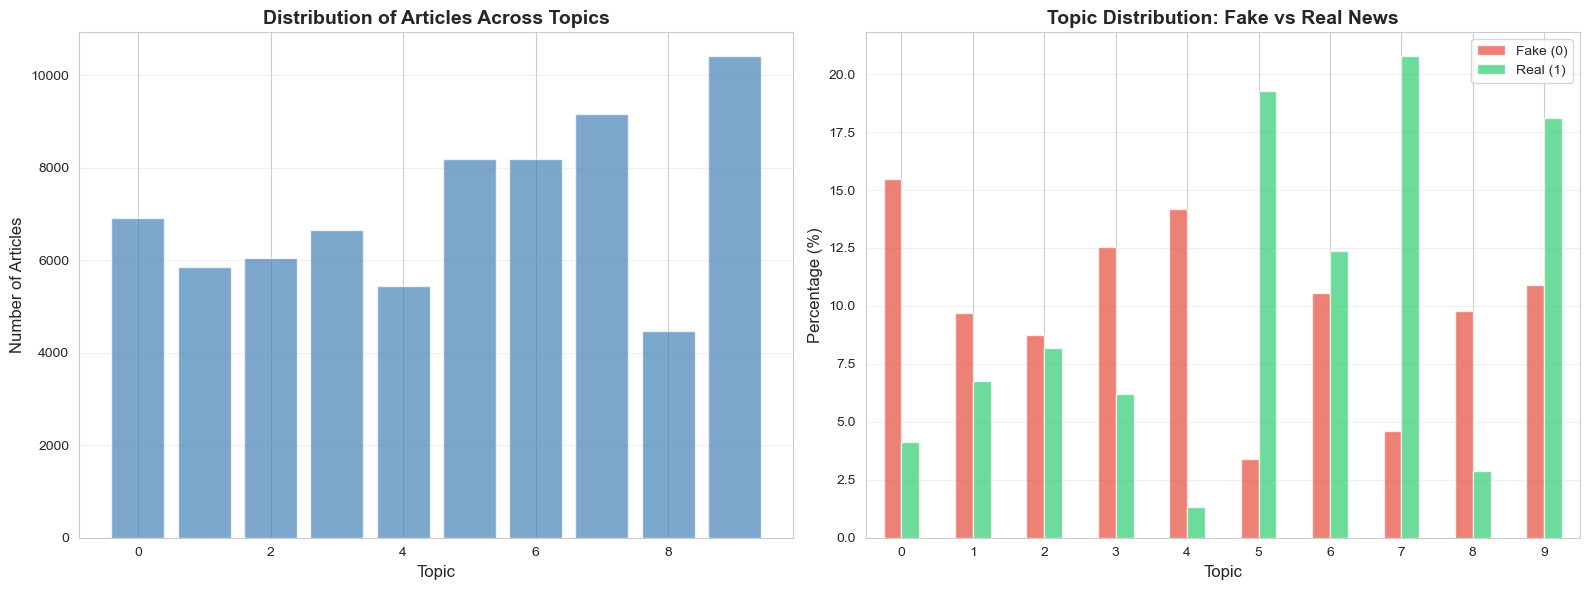

In [11]:
# Visualize topic distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall topic distribution
topic_counts = df['dominant_topic'].value_counts().sort_index()
axes[0].bar(topic_counts.index, topic_counts.values, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Topic', fontsize=12)
axes[0].set_ylabel('Number of Articles', fontsize=12)
axes[0].set_title('Distribution of Articles Across Topics', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Topic distribution by label (Fake vs Real)
topic_by_label = pd.crosstab(df['dominant_topic'], df['label'], normalize='columns') * 100
topic_by_label.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'], alpha=0.7)
axes[1].set_xlabel('Topic', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].set_title('Topic Distribution: Fake vs Real News', fontsize=14, fontweight='bold')
axes[1].legend(['Fake (0)', 'Real (1)'], fontsize=10)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Word Clouds for Topics


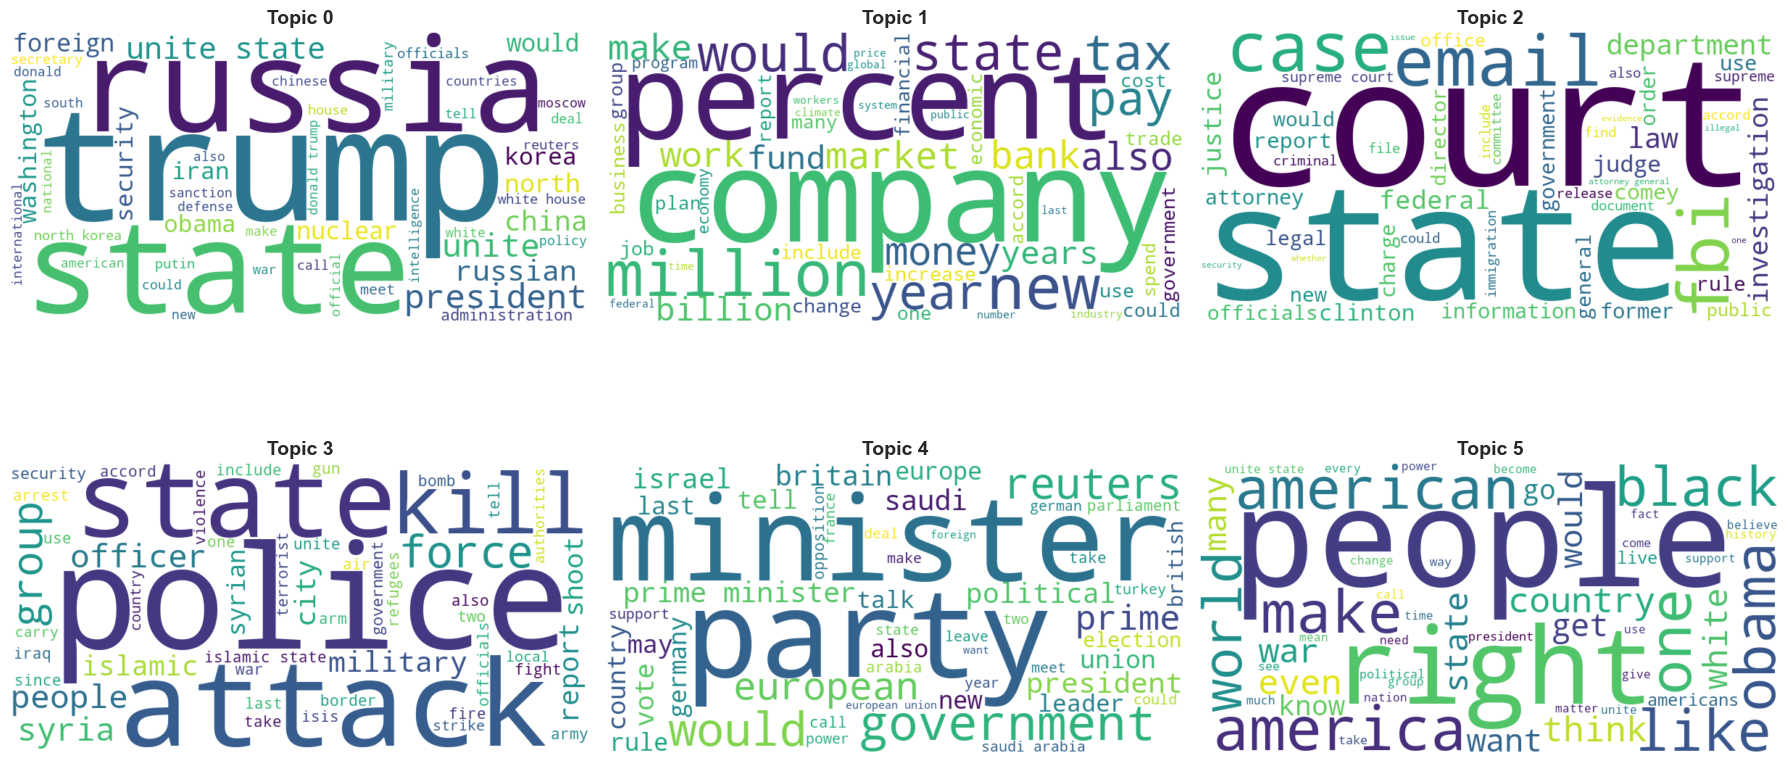

In [12]:
def create_topic_wordcloud(model, feature_names, topic_idx, n_words=50):
    """Create word cloud for a specific topic."""
    topic = model.components_[topic_idx]
    top_indices = topic.argsort()[-n_words:][::-1]
    
    # Create word frequency dictionary
    word_freq = {feature_names[i]: topic[i] for i in top_indices}
    
    # Generate word cloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='viridis',
        relative_scaling=0.5
    ).generate_from_frequencies(word_freq)
    
    return wordcloud

# Create word clouds for first 6 topics
n_cols = 3
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
axes = axes.flatten()

for topic_idx in range(min(6, N_TOPICS)):
    wordcloud = create_topic_wordcloud(lda_model, feature_names, topic_idx)
    
    axes[topic_idx].imshow(wordcloud, interpolation='bilinear')
    axes[topic_idx].set_title(f'Topic {topic_idx}', fontsize=14, fontweight='bold')
    axes[topic_idx].axis('off')

# Hide empty subplots
for idx in range(min(6, N_TOPICS), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


## 10. Sample Articles from Each Topic


In [13]:
def display_sample_articles(df, topic_idx, n_samples=2):
    """Display sample articles from a specific topic."""
    topic_articles = df[df['dominant_topic'] == topic_idx].nlargest(n_samples, f'topic_{topic_idx}_prob')
    
    print(f"\\n{'='*80}")
    print(f"TOPIC {topic_idx} - Sample Articles")
    print(f"{'='*80}\\n")
    
    for idx, (_, row) in enumerate(topic_articles.iterrows(), 1):
        print(f"Article {idx}:")
        print(f"Title: {row['title'][:100]}...")
        print(f"Label: {'FAKE' if row['label'] == 0 else 'REAL'}")
        print(f"Topic Probability: {row[f'topic_{topic_idx}_prob']:.3f}")
        print(f"Text Preview: {row['text'][:200]}...")
        print("-" * 80)

# Display samples from first 3 topics
for topic_idx in range(min(3, N_TOPICS)):
    display_sample_articles(df, topic_idx, n_samples=2)


\n================================================================================
TOPIC 0 - Sample Articles
================================================================================\n
Article 1:
Title: Tillerson, Lavrov agree to continue North Korea diplomacy: U.S. State Department...
Label: FAKE
Topic Probability: 0.996
Text Preview: WASHINGTON (Reuters) - The United States and Russia have agreed to continue diplomatic efforts to resolve the crisis over North Korea s development of nuclear missiles capable of hitting the United St...
--------------------------------------------------------------------------------
Article 2:
Title: Tillerson, Lavrov agree to continue North Korea diplomacy: U.S. State Department...
Label: FAKE
Topic Probability: 0.996
Text Preview: WASHINGTON (Reuters) - The United States and Russia have agreed to continue diplomatic efforts to resolve the crisis over North Korea s development of nuclear missiles capable of hitting the United St...
-------------

## 11. Topic Analysis by Label (Fake vs Real)


In [14]:
# Analyze which topics are more associated with fake vs real news
topic_label_analysis = df.groupby('dominant_topic').agg({
    'label': ['count', 'mean'],
    'text': 'count'
}).round(3)

topic_label_analysis.columns = ['Total Articles', 'Real News Ratio', 'Count']
topic_label_analysis['Fake News Ratio'] = 1 - topic_label_analysis['Real News Ratio']
topic_label_analysis = topic_label_analysis[['Total Articles', 'Fake News Ratio', 'Real News Ratio']]

print("\\nTopic Analysis by Label:")
print("="*80)
print(topic_label_analysis)

# Identify topics strongly associated with fake or real news
print("\\n" + "="*80)
print("Topics Most Associated with Fake News:")
fake_topics = topic_label_analysis.nlargest(3, 'Fake News Ratio')
for topic_idx in fake_topics.index:
    print(f"  Topic {topic_idx}: {fake_topics.loc[topic_idx, 'Fake News Ratio']*100:.1f}% fake")

print("\\nTopics Most Associated with Real News:")
real_topics = topic_label_analysis.nlargest(3, 'Real News Ratio')
for topic_idx in real_topics.index:
    print(f"  Topic {topic_idx}: {real_topics.loc[topic_idx, 'Real News Ratio']*100:.1f}% real")


\nTopic Analysis by Label:
                Total Articles  Fake News Ratio  Real News Ratio
dominant_topic                                                  
0                         6922            0.784            0.216
1                         5863            0.580            0.420
2                         6052            0.507            0.493
3                         6646            0.661            0.339
4                         5448            0.912            0.088
5                         8194            0.146            0.854
6                         8193            0.452            0.548
7                         9156            0.176            0.824
8                         4480            0.766            0.234
9                        10410            0.368            0.632
\n================================================================================
Topics Most Associated with Fake News:
  Topic 4: 91.2% fake
  Topic 0: 78.4% fake
  Topic 8: 76.6% fake
\nTop

## 12. Topic Similarity Heatmap


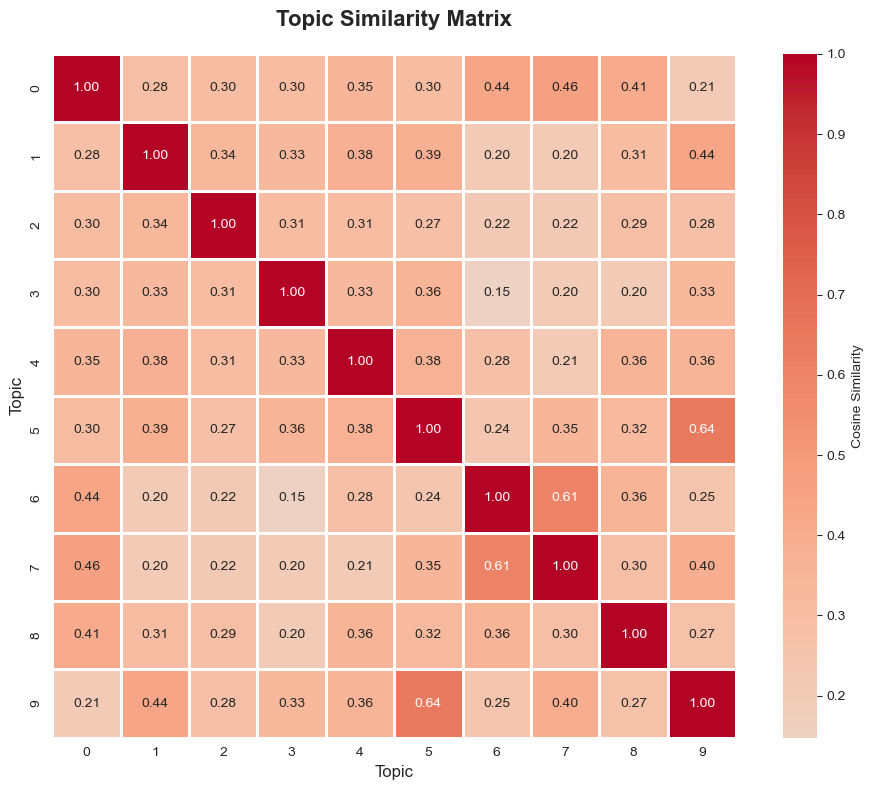

In [15]:
# Calculate topic similarity based on word distributions
topic_similarity = cosine_similarity(lda_model.components_)

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    topic_similarity,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={'label': 'Cosine Similarity'}
)
plt.title('Topic Similarity Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Topic', fontsize=12)
plt.ylabel('Topic', fontsize=12)
plt.tight_layout()
plt.show()


## 13. Save Results


In [16]:
# Save enhanced dataset with topic assignments
output_path = project_root / "data" / "processed" / "dataset_with_topics.csv"

# Select columns to save
columns_to_save = ['id', 'title', 'text', 'label', 'dominant_topic'] + \
                  [f'topic_{i}_prob' for i in range(N_TOPICS)]

df[columns_to_save].to_csv(output_path, index=False)

print(f"✓ Saved dataset with topic assignments to:")
print(f"  {output_path}")
print(f"\\nSaved {len(df):,} articles with {N_TOPICS} topic probabilities")


✓ Saved dataset with topic assignments to:
  /Users/alanye/Fake-News-Group-3/data/processed/dataset_with_topics.csv
\nSaved 71,364 articles with 10 topic probabilities


In [17]:
# Save topic keywords
import pickle

topic_keywords = {}
for topic_idx, topic in enumerate(lda_model.components_):
    top_indices = topic.argsort()[-20:][::-1]
    topic_keywords[f'topic_{topic_idx}'] = [feature_names[i] for i in top_indices]

keywords_path = project_root / "results" / "models" / "topic_keywords.pkl"
keywords_path.parent.mkdir(parents=True, exist_ok=True)

with open(keywords_path, 'wb') as f:
    pickle.dump(topic_keywords, f)

print(f"✓ Saved topic keywords to: {keywords_path}")


✓ Saved topic keywords to: /Users/alanye/Fake-News-Group-3/results/models/topic_keywords.pkl


# Part 2: NMF Topic Modeling

Now we'll apply Non-negative Matrix Factorization (NMF) and compare it with LDA.


## 14. Train NMF Topic Model


In [23]:
# NMF Parameters (same as LDA for fair comparison)
print(f"Training NMF model with {N_TOPICS} topics...")
print("This may take a few minutes...\n")

# Train NMF model
nmf_model = NMF(
    n_components=N_TOPICS,
    random_state=RANDOM_STATE,
    max_iter=200,
    init='nndsvda',  # Non-negative Double Singular Value Decomposition (recommended)
    l1_ratio=0.0,    # L2 regularization
    solver='cd'      # Coordinate Descent solver (faster for large datasets)
)

nmf_output = nmf_model.fit_transform(tfidf_matrix)

print("\n✓ NMF model trained successfully")
print(f"Reconstruction error: {nmf_model.reconstruction_err_:.2f}")
print(f"Number of iterations: {nmf_model.n_iter_}")


Training NMF model with 10 topics...
This may take a few minutes...


✓ NMF model trained successfully
Reconstruction error: 252.66
Number of iterations: 200


## 15. Display NMF Topics


In [24]:
print("Top 15 words for each NMF topic:")
nmf_topics = display_topics(nmf_model, tfidf_feature_names, n_top_words=15)


Top 15 words for each NMF topic:
\n================================================================================
Topic 0:
people, like, one, get, time, make, know, think, go, even, want, take, world, live, see
\n================================================================================
Topic 1:
trump, donald, donald trump, president, campaign, republican, white, trump say, image, white house, presidential, cruz, tweet, go, election
\n================================================================================
Topic 2:
party, vote, minister, election, percent, european, poll, britain, government, prime minister, prime, parliament, brexit, voters, union
\n================================================================================
Topic 3:
clinton, hillary, hillary clinton, sanders, email, campaign, democratic, state, foundation, presidential, mrs clinton, clinton campaign, vote, mrs, voters
\n==============================================================================

## 16. Assign Documents to NMF Topics


In [25]:
# Add NMF topic assignments to dataframe
df['nmf_dominant_topic'] = nmf_output.argmax(axis=1)

# Add NMF topic probabilities (normalized)
nmf_probs = nmf_output / nmf_output.sum(axis=1, keepdims=True)
for i in range(N_TOPICS):
    df[f'nmf_topic_{i}_prob'] = nmf_probs[:, i]

print(f"✓ Assigned {len(df):,} documents to NMF topics")
print(f"\nNMF Topic distribution:")
print(df['nmf_dominant_topic'].value_counts().sort_index())


✓ Assigned 71,364 documents to NMF topics

NMF Topic distribution:
nmf_dominant_topic
0    13137
1    13122
2     5289
3     5745
4     6828
5     2380
6     3371
7     6173
8     8876
9     6443
Name: count, dtype: int64


## 17. NMF Visualizations


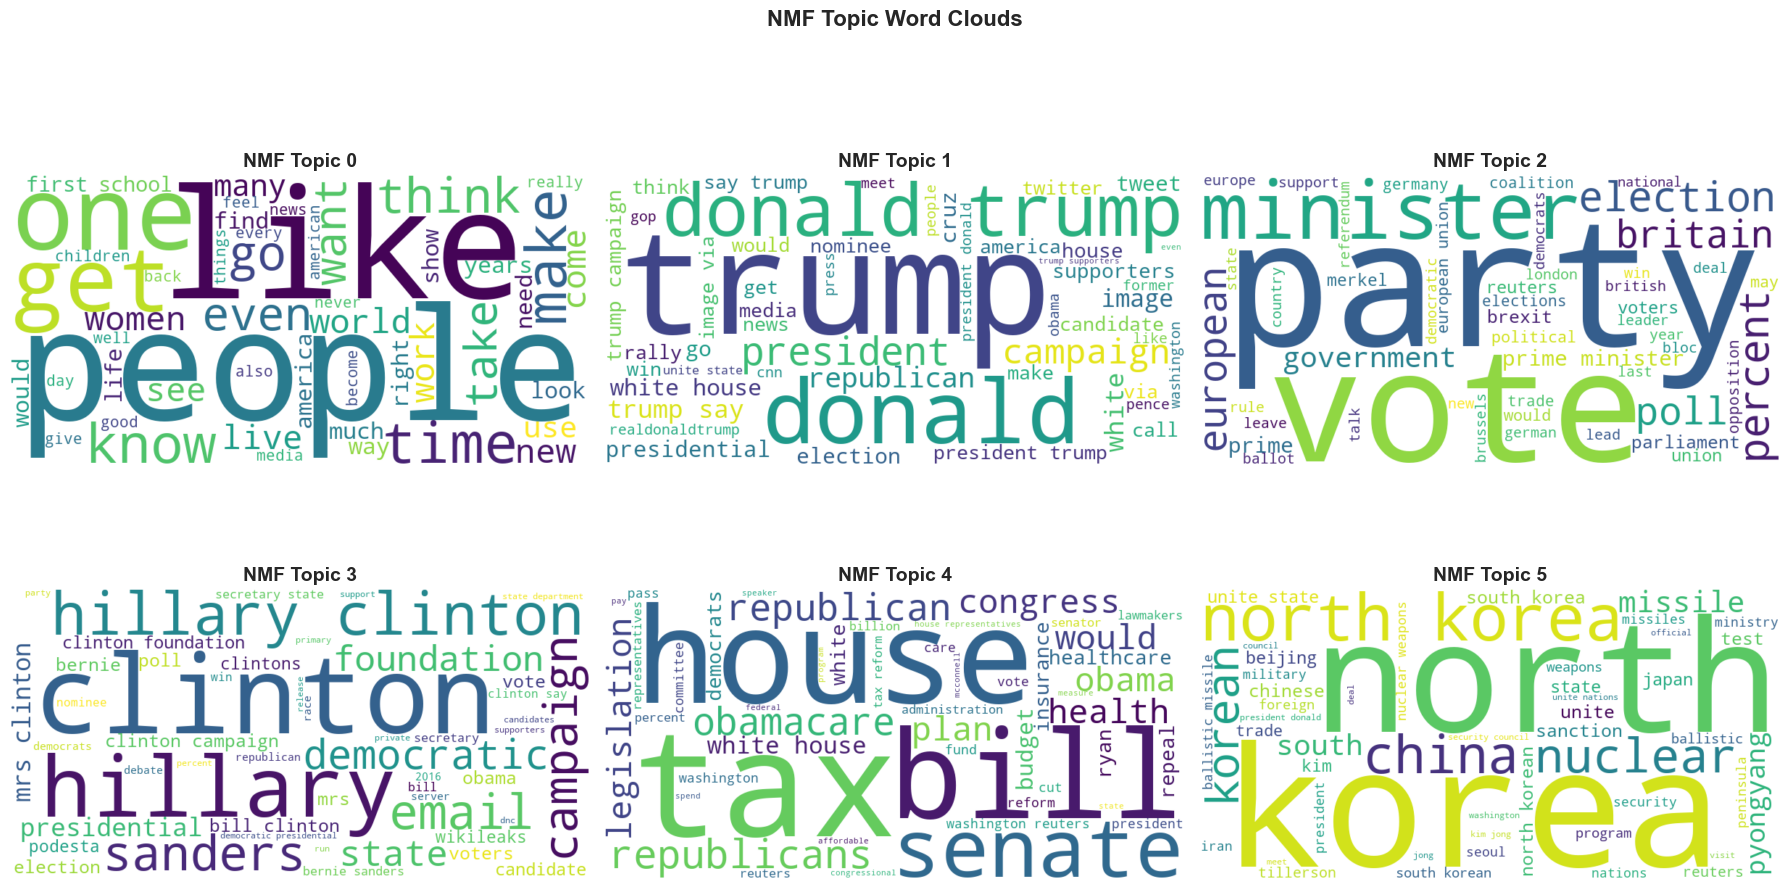

In [26]:
# Create word clouds for first 6 NMF topics
n_cols = 3
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
axes = axes.flatten()

for topic_idx in range(min(6, N_TOPICS)):
    wordcloud = create_topic_wordcloud(nmf_model, tfidf_feature_names, topic_idx)
    
    axes[topic_idx].imshow(wordcloud, interpolation='bilinear')
    axes[topic_idx].set_title(f'NMF Topic {topic_idx}', fontsize=14, fontweight='bold')
    axes[topic_idx].axis('off')

# Hide empty subplots
for idx in range(min(6, N_TOPICS), len(axes)):
    axes[idx].axis('off')

plt.suptitle('NMF Topic Word Clouds', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


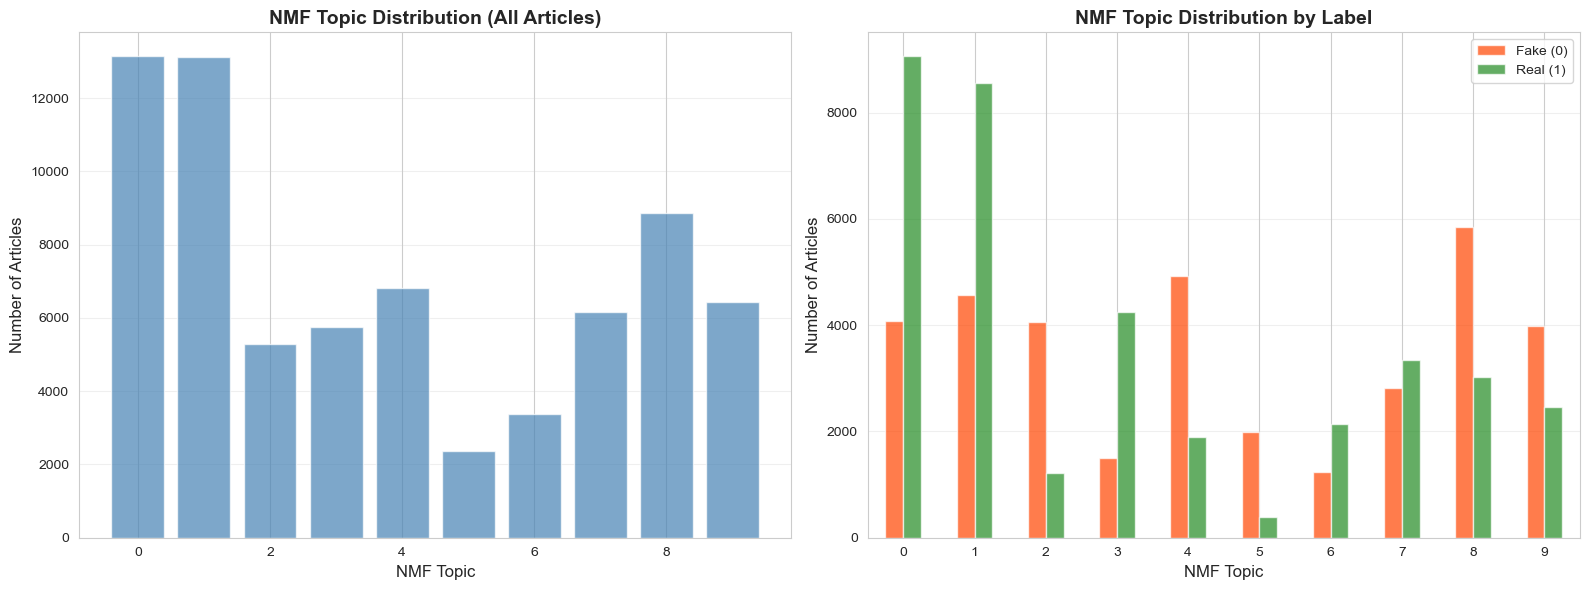

In [27]:
# NMF Topic distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall distribution
topic_counts = df['nmf_dominant_topic'].value_counts().sort_index()
axes[0].bar(topic_counts.index, topic_counts.values, color='steelblue', alpha=0.7)
axes[0].set_xlabel('NMF Topic', fontsize=12)
axes[0].set_ylabel('Number of Articles', fontsize=12)
axes[0].set_title('NMF Topic Distribution (All Articles)', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Distribution by label
nmf_topic_label = df.groupby(['nmf_dominant_topic', 'label']).size().unstack(fill_value=0)
nmf_topic_label.plot(kind='bar', stacked=False, ax=axes[1], color=['orangered', 'forestgreen'], alpha=0.7)
axes[1].set_xlabel('NMF Topic', fontsize=12)
axes[1].set_ylabel('Number of Articles', fontsize=12)
axes[1].set_title('NMF Topic Distribution by Label', fontsize=14, fontweight='bold')
axes[1].legend(['Fake (0)', 'Real (1)'], loc='upper right')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 18. NMF Topic Analysis by Label


In [28]:
# Analyze which NMF topics are more associated with fake vs real news
nmf_topic_label_analysis = df.groupby('nmf_dominant_topic').agg({
    'label': ['count', 'mean'],
    'text': 'count'
}).round(3)

nmf_topic_label_analysis.columns = ['Total Articles', 'Real News Ratio', 'Count']
nmf_topic_label_analysis['Fake News Ratio'] = 1 - nmf_topic_label_analysis['Real News Ratio']
nmf_topic_label_analysis = nmf_topic_label_analysis[['Total Articles', 'Fake News Ratio', 'Real News Ratio']]

print("\nNMF Topic Analysis by Label:")
print("="*80)
print(nmf_topic_label_analysis)

# Identify NMF topics strongly associated with fake or real news
print("\n" + "="*80)
print("NMF Topics Most Associated with Fake News:")
nmf_fake_topics = nmf_topic_label_analysis.nlargest(3, 'Fake News Ratio')
for topic_idx in nmf_fake_topics.index:
    print(f"  Topic {topic_idx}: {nmf_fake_topics.loc[topic_idx, 'Fake News Ratio']*100:.1f}% fake")

print("\nNMF Topics Most Associated with Real News:")
nmf_real_topics = nmf_topic_label_analysis.nlargest(3, 'Real News Ratio')
for topic_idx in nmf_real_topics.index:
    print(f"  Topic {topic_idx}: {nmf_real_topics.loc[topic_idx, 'Real News Ratio']*100:.1f}% real")



NMF Topic Analysis by Label:
                    Total Articles  Fake News Ratio  Real News Ratio
nmf_dominant_topic                                                  
0                            13137            0.311            0.689
1                            13122            0.348            0.652
2                             5289            0.768            0.232
3                             5745            0.261            0.739
4                             6828            0.722            0.278
5                             2380            0.834            0.166
6                             3371            0.365            0.635
7                             6173            0.458            0.542
8                             8876            0.659            0.341
9                             6443            0.619            0.381

NMF Topics Most Associated with Fake News:
  Topic 5: 83.4% fake
  Topic 2: 76.8% fake
  Topic 4: 72.2% fake

NMF Topics Most Associated with

## 19. Comparison: LDA vs NMF


In [29]:
# Compare topic assignments between LDA and NMF
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Calculate agreement metrics
ari = adjusted_rand_score(df['dominant_topic'], df['nmf_dominant_topic'])
nmi = normalized_mutual_info_score(df['dominant_topic'], df['nmf_dominant_topic'])

print("LDA vs NMF Topic Assignment Comparison")
print("="*80)
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"  (1.0 = perfect agreement, 0.0 = random assignment)")
print(f"\nNormalized Mutual Information (NMI): {nmi:.4f}")
print(f"  (1.0 = perfect agreement, 0.0 = independent)")

# Cross-tabulation of topic assignments
print("\n" + "="*80)
print("Cross-tabulation: LDA Topics (rows) vs NMF Topics (columns)")
print("="*80)
crosstab = pd.crosstab(df['dominant_topic'], df['nmf_dominant_topic'], margins=True)
print(crosstab)


LDA vs NMF Topic Assignment Comparison
Adjusted Rand Index (ARI): 0.2230
  (1.0 = perfect agreement, 0.0 = random assignment)

Normalized Mutual Information (NMI): 0.3327
  (1.0 = perfect agreement, 0.0 = independent)

Cross-tabulation: LDA Topics (rows) vs NMF Topics (columns)
nmf_dominant_topic      0      1     2     3     4     5     6     7     8  \
dominant_topic                                                               
0                     186   1190    68    58   348  1870   361     8  2654   
1                    1435    621   398   207  1865   187    76   121   281   
2                      54    174    57   631   155    14  1757   413    61   
3                     135     56    82    29    35    57    25  2771  3269   
4                      34    126  3253    16    42    46     5   171  1299   
5                    2629   1822   242   487   275    42    70   965   798   
6                     147   3589   954  2807   253     7    79    83    52   
7                  

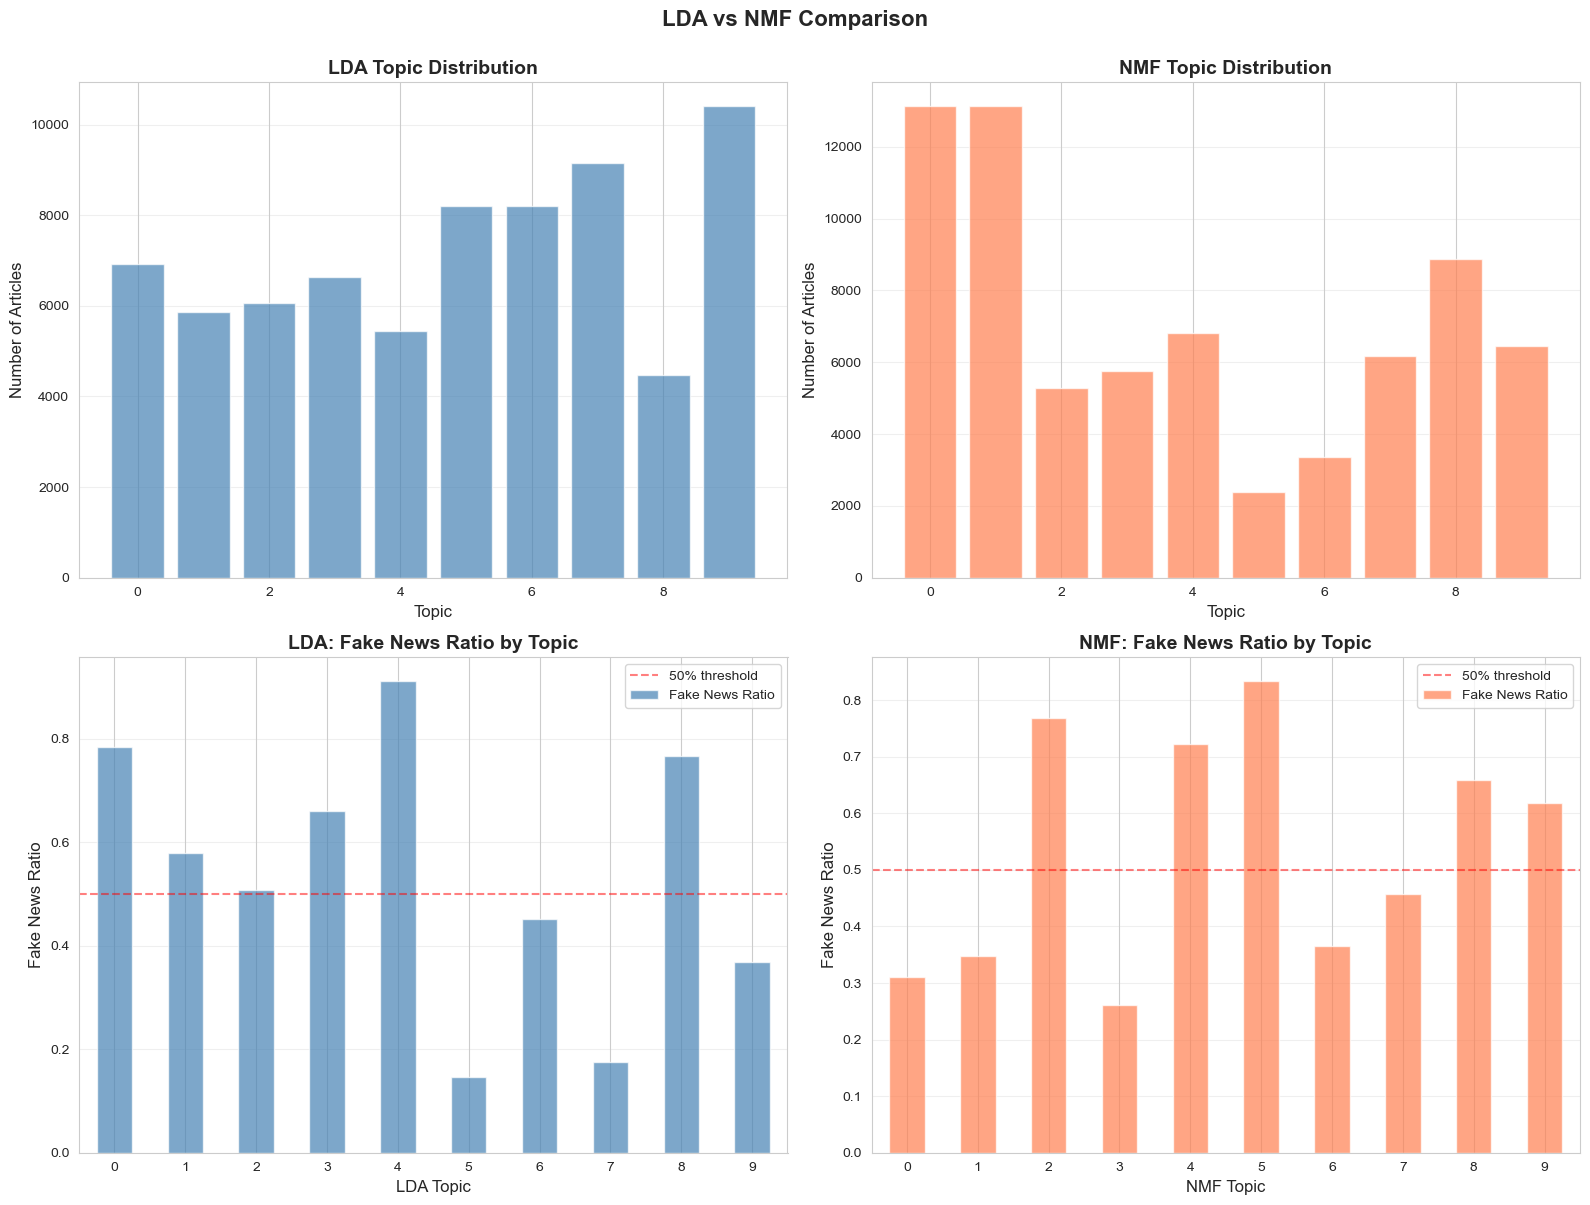

In [31]:
# Visual comparison: Topic distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# LDA overall distribution
lda_counts = df['dominant_topic'].value_counts().sort_index()
axes[0, 0].bar(lda_counts.index, lda_counts.values, color='steelblue', alpha=0.7)
axes[0, 0].set_xlabel('Topic', fontsize=12)
axes[0, 0].set_ylabel('Number of Articles', fontsize=12)
axes[0, 0].set_title('LDA Topic Distribution', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# NMF overall distribution
nmf_counts = df['nmf_dominant_topic'].value_counts().sort_index()
axes[0, 1].bar(nmf_counts.index, nmf_counts.values, color='coral', alpha=0.7)
axes[0, 1].set_xlabel('Topic', fontsize=12)
axes[0, 1].set_ylabel('Number of Articles', fontsize=12)
axes[0, 1].set_title('NMF Topic Distribution', fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# LDA: Fake vs Real ratio by topic
topic_label_analysis['Fake News Ratio'].plot(kind='bar', ax=axes[1, 0], color='steelblue', alpha=0.7)
axes[1, 0].set_xlabel('LDA Topic', fontsize=12)
axes[1, 0].set_ylabel('Fake News Ratio', fontsize=12)
axes[1, 0].set_title('LDA: Fake News Ratio by Topic', fontsize=14, fontweight='bold')
axes[1, 0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50% threshold')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=0)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# NMF: Fake vs Real ratio by topic
nmf_topic_label_analysis['Fake News Ratio'].plot(kind='bar', ax=axes[1, 1], color='coral', alpha=0.7)
axes[1, 1].set_xlabel('NMF Topic', fontsize=12)
axes[1, 1].set_ylabel('Fake News Ratio', fontsize=12)
axes[1, 1].set_title('NMF: Fake News Ratio by Topic', fontsize=14, fontweight='bold')
axes[1, 1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50% threshold')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.suptitle('LDA vs NMF Comparison', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


### Key Differences Between LDA and NMF

**LDA (Latent Dirichlet Allocation):**
- Probabilistic generative model
- Documents are mixtures of topics, topics are mixtures of words
- Works with count vectors (word frequencies)
- Better for discovering semantic themes
- Topics can overlap more naturally

**NMF (Non-negative Matrix Factorization):**
- Linear algebra factorization method
- Decomposes document-term matrix into document-topic and topic-word matrices
- Works better with TF-IDF (term importance)
- Often produces more distinct, interpretable topics
- Faster training on large datasets

**Which is better?**
- Compare the coherence of topics (do they make semantic sense?)
- Check which better separates fake vs real news
- Consider computational efficiency for your use case


## 20. Save NMF Results


In [ ]:
# Save enhanced dataset with both LDA and NMF topic assignments
output_path_nmf = project_root / "data" / "processed" / "dataset_with_topics_lda_nmf.csv"

# Select columns to save (including both LDA and NMF topics)
columns_to_save = ['id', 'title', 'text', 'label', 
                   'dominant_topic', 'nmf_dominant_topic'] + \
                  [f'topic_{i}_prob' for i in range(N_TOPICS)] + \
                  [f'nmf_topic_{i}_prob' for i in range(N_TOPICS)]

df[columns_to_save].to_csv(output_path_nmf, index=False)

print(f"✓ Saved dataset with LDA and NMF topic assignments to:")
print(f"  {output_path_nmf}")
print(f"\nSaved {len(df):,} articles with:")
print(f"  - {N_TOPICS} LDA topic probabilities")
print(f"  - {N_TOPICS} NMF topic probabilities")


In [ ]:
# Save NMF topic keywords
nmf_topic_keywords = {}
for topic_idx, topic in enumerate(nmf_model.components_):
    top_indices = topic.argsort()[-20:][::-1]
    nmf_topic_keywords[f'nmf_topic_{topic_idx}'] = [tfidf_feature_names[i] for i in top_indices]

nmf_keywords_path = project_root / "results" / "models" / "nmf_topic_keywords.pkl"

with open(nmf_keywords_path, 'wb') as f:
    pickle.dump(nmf_topic_keywords, f)

print(f"✓ Saved NMF topic keywords to: {nmf_keywords_path}")


## Summary

Both LDA and NMF have been successfully implemented. Compare their results and choose the best approach for your classification task!


## Summary and Conclusions

This notebook has implemented two complementary topic modeling approaches:

### LDA Results
- Discovered probabilistic topics using word count features
- Identified topics strongly associated with fake vs real news
- Saved topic assignments and probabilities for feature engineering

### NMF Results
- Discovered factorized topics using TF-IDF features
- Compared topic coherence and interpretability with LDA
- Provided alternative perspective on document grouping

### Next Steps
1. **Compare topic quality**: Which method produces more interpretable topics for your use case?
2. **Feature engineering**: Use topic probabilities as features for classification models
3. **Ensemble approach**: Combine both LDA and NMF features for better performance
4. **Fine-tuning**: Experiment with different numbers of topics (5, 15, 20, etc.)
5. **Coherence metrics**: Implement topic coherence scores to quantitatively evaluate models


## 17. NMF Topic Distribution Visualizations


## 14. Summary


In [30]:
print("="*80)
print("TOPIC MODELING SUMMARY")
print("="*80)
print(f"\\nTotal articles analyzed: {len(df):,}")
print(f"Number of topics: {N_TOPICS}")
print(f"Vocabulary size: {len(feature_names):,} terms")
print(f"\\nModel Performance:")
print(f"  Perplexity: {lda_model.perplexity(doc_term_matrix):.2f}")
print(f"  Log-likelihood: {lda_model.score(doc_term_matrix):.2f}")

print(f"\\nTopic Distribution:")
for topic_idx in range(N_TOPICS):
    count = (df['dominant_topic'] == topic_idx).sum()
    pct = count / len(df) * 100
    print(f"  Topic {topic_idx}: {count:,} articles ({pct:.1f}%)")

print(f"\\nOutput files:")
print(f"  - Dataset with topics: dataset_with_topics.csv")
print(f"  - Topic keywords: topic_keywords.pkl")
print("\\n" + "="*80)
print("✓ Topic analysis complete!")
print("="*80)


TOPIC MODELING SUMMARY
\nTotal articles analyzed: 71,364
Number of topics: 10
Vocabulary size: 5,000 terms
\nModel Performance:
  Perplexity: 1720.11
  Log-likelihood: -138719398.14
\nTopic Distribution:
  Topic 0: 6,922 articles (9.7%)
  Topic 1: 5,863 articles (8.2%)
  Topic 2: 6,052 articles (8.5%)
  Topic 3: 6,646 articles (9.3%)
  Topic 4: 5,448 articles (7.6%)
  Topic 5: 8,194 articles (11.5%)
  Topic 6: 8,193 articles (11.5%)
  Topic 7: 9,156 articles (12.8%)
  Topic 8: 4,480 articles (6.3%)
  Topic 9: 10,410 articles (14.6%)
\nOutput files:
  - Dataset with topics: dataset_with_topics.csv
  - Topic keywords: topic_keywords.pkl
\n================================================================================
✓ Topic analysis complete!


## Next Steps

Based on this topic analysis, you can:

1. **Feature Engineering**: Use topic probabilities as features for classification models
2. **Topic-Based Analysis**: Analyze linguistic patterns within each topic
3. **Temporal Analysis**: Track how topics evolve over time (if date information is available)
4. **Cross-Topic Analysis**: Study how fake news differs from real news within the same topic
5. **Model Refinement**: Experiment with different numbers of topics or different algorithms (NMF, LSA)

The topic assignments have been saved to `dataset_with_topics.csv` for use in downstream analysis and modeling.
